# 19 · Asynchronous actions, cancellation, and recovery

## Learning objectives

- Run a minimal simulated action server.
- Map goal acceptance and result status to BT status.
- Exercise rejection, timeout, cancellation, preemption, and recovery.

**Environment:** ROS 2 Jazzy, sourced workspace, and the ROS notebook kernel from the README. Every ROS example owns and closes its context; run cells in order. Do not call `rclpy.spin` on nodes already managed by `RosSession`.

## Intuition

A long-running service cannot report progress or accept protocol-level cancellation. A ROS
action can. We reuse `example_interfaces/action/Fibonacci`: its goal specifies an order,
feedback reports the growing sequence, and its result contains the sequence. The server
intentionally computes slowly so asynchronous behavior is visible. It is an arithmetic
teaching action, not a navigation interface.

| Action stage | BT result |
|---|---|
| Server discovery, acceptance pending, or result pending | RUNNING |
| Accepted goal finishes with SUCCEEDED | SUCCESS |
| Goal rejected, aborted, canceled, transport error, or deadline exceeded | FAILURE |
| Parent withdraws request | INVALID locally; request cancellation remotely |

The server allows one goal at a time and rejects orders outside 1–20. A reentrant callback
group and multiple executor threads allow cancellation callbacks to run while its bounded
simulated worker sleeps. Real drivers should use their own asynchronous work mechanisms.

In [1]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display
from behavior_trees_tutorial.ros_nodes.session import RosSession
from uuid import uuid4
from time import monotonic, sleep
from behavior_trees_tutorial.ros_nodes.servers import FibonacciServer
from behavior_trees_tutorial.ros_nodes.adapters import FibonacciAction

def run_until_terminal(root, timeout=5.0, history=None):
    deadline = monotonic() + timeout
    results = []
    while monotonic() < deadline:
        root.tick_once()
        results.append(root.status.name)
        if history is not None:
            history.append({node.name: node.status.name for node in root.iterate()})
        if root.status is not Status.RUNNING:
            return results
        sleep(0.01)  # Notebook pacing only; never put this in a BT update.
    root.stop(Status.INVALID)
    raise TimeoutError("Tree did not finish")

## Minimal working example
The first tick sends a goal and returns. Future completions are processed by the executor.
The leaf checks those futures on later ticks. The notebook polling loop is an application
runner, not part of the behavior itself.

Trace: ['RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'SUCCESS'] Feedback: [[0, 1, 1], [0, 1, 1, 2], [0, 1, 1, 2, 3], [0, 1, 1, 2, 3, 5], [0, 1, 1, 2, 3, 5, 8], [0, 1, 1, 2, 3, 5, 8, 13]]


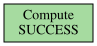

In [2]:
with RosSession() as ros:
    namespace = "/action_" + uuid4().hex
    server = ros.add(FibonacciServer(context=ros.context, namespace=namespace))
    node = ros.node("action_tree", namespace=namespace)
    action = FibonacciAction("Compute", node)
    try:
        ros.wait(action.client.server_is_ready)
        results = run_until_terminal(action)
        assert results[0] == "RUNNING" and results[-1] == "SUCCESS"
        assert len(action.feedback) > 0
        print("Trace:", results, "Feedback:", action.feedback)
        display(diagram(action))
    finally:
        action.stop(Status.INVALID)
        ros.wait(lambda: action.goal_future is None or action.goal_future.done())
        ros.wait(lambda: not server.busy)
        action.shutdown()

## Step-by-step implementation
`initialise` creates a deadline; `update` starts a request once, then polls acceptance and
result futures. `terminate` attaches cancellation to the goal-acceptance future, so even a
request interrupted before acceptance is eventually canceled. Completion and cancellation
are asynchronous: do not destroy the client immediately after requesting cancel.

A timeout bounds the leaf's waiting time, not the physical stopping time. Here we keep the
executor alive until the server confirms it is idle. A production controller should require
an explicit stopped-state acknowledgement before conflicting commands.

In [3]:
import inspect
print(inspect.getsource(FibonacciAction.update))
print(inspect.getsource(FibonacciAction.terminate))

    def update(self):
        if monotonic() >= self.deadline:
            self.feedback_message = "deadline exceeded"
            return Status.FAILURE
        if self.goal_future is None:
            if not self.client.server_is_ready():
                return Status.RUNNING
            self.goal_future = self.client.send_goal_async(
                Fibonacci.Goal(order=self.order),
                feedback_callback=lambda message: self.feedback.append(list(message.feedback.sequence)),
            )
        try:
            if not self.goal_future.done():
                return Status.RUNNING
            goal = self.goal_future.result()
            if not goal.accepted:
                return Status.FAILURE
            if self.result_future is None:
                self.result_future = goal.get_result_async()
            if not self.result_future.done():
                return Status.RUNNING
            result = self.result_future.result()
            return (Status.SUCCESS if result

### Timeout and recovery
A 20-step goal cannot finish within 0.12 seconds at 0.04 seconds per step. The decorator
invalidates it, triggering cancellation. Recovery waits for the simulated server to become
idle before reporting success. The server's `busy` flag is available here because this is
an in-process test; a distributed system needs an acknowledged result or status interface.

The memory selector may mark its earlier failed branch INVALID while resuming recovery.
We record the timeout failure when it occurs instead of assuming it remains the final displayed status.

Canceled goals: 1


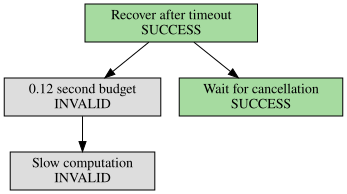

In [4]:
with RosSession() as ros:
    namespace = "/timeout_" + uuid4().hex
    server = ros.add(FibonacciServer(context=ros.context, namespace=namespace))
    node = ros.node("timeout_tree", namespace=namespace)
    action = FibonacciAction("Slow computation", node, order=20)
    limited = pt.decorators.Timeout("0.12 second budget", action, duration=0.12)
    root = pt.composites.Selector("Recover after timeout", memory=True, children=[
        limited, Function("Wait for cancellation", lambda: Status.RUNNING if server.busy else Status.SUCCESS)])
    try:
        ros.wait(action.client.server_is_ready)
        history = []
        results = run_until_terminal(root, history=history)
        ros.wait(lambda: server.cancelled == 1)
        assert root.status is Status.SUCCESS
        assert any(row["0.12 second budget"] == "FAILURE" for row in history)
        print("Canceled goals:", server.cancelled)
        display(diagram(root))
    finally:
        root.stop(Status.INVALID)
        ros.wait(lambda: action.goal_future is None or action.goal_future.done())
        ros.wait(lambda: not server.busy)
        action.shutdown()

### Priority preemption and rejection
Now an urgent local condition displaces the action. Its INVALID state is different from a
server-reported FAILURE. After cancellation completes, a malformed goal demonstrates explicit
rejection. Setting `order=0` does not mean “complete instantly”; it violates this server's contract.

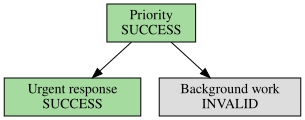

In [5]:
with RosSession() as ros:
    namespace = "/preempt_" + uuid4().hex
    server = ros.add(FibonacciServer(context=ros.context, namespace=namespace))
    node = ros.node("priority_tree", namespace=namespace)
    urgent = {"value": False}
    action = FibonacciAction("Background work", node, order=20)
    root = pt.composites.Selector("Priority", memory=False, children=[
        Function("Urgent response", lambda: Status.SUCCESS if urgent["value"] else Status.FAILURE), action])
    rejected = FibonacciAction("Invalid request", node, order=0)
    try:
        ros.wait(action.client.server_is_ready)
        root.tick_once()
        ros.wait(lambda: server.busy)
        urgent["value"] = True
        root.tick_once()
        assert action.status is Status.INVALID
        ros.wait(lambda: server.cancelled == 1 and not server.busy)
        display(diagram(root))
        assert run_until_terminal(rejected)[-1] == "FAILURE"
    finally:
        root.stop(Status.INVALID)
        rejected.stop(Status.INVALID)
        ros.wait(lambda: action.goal_future is None or action.goal_future.done())
        ros.wait(lambda: not server.busy)
        action.shutdown()
        rejected.shutdown()

## Interactive demonstration
Explore local lifecycle transitions with Tick and Reset below. To change real action
parameters, edit `order` or `duration` above and rerun the complete context cell; each run
starts fresh ROS resources and closes them. Widgets deliberately retain no action clients.

In [6]:
display(playground(lambda: CountTicks("Action progress model", ticks=5)))

## Key observations

A goal acceptance is not a successful result. Cancellation is a protocol, and preemption must allow time for it to complete. Service requests have no equivalent cancellation guarantee.

## Exercises

1. Set the leaf’s own timeout to 0.12 and compare with the decorator.
2. Interrupt immediately after send_goal_async, before acceptance.
3. Replace successful recovery with a bounded retry after cancellation.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 19).

## Summary

Asynchronous action leaves keep ticks responsive while the executor handles feedback and results. Explicit cleanup is part of correctness.